# Phase 5 — Modèle de base

Objectif : entraîner un premier modèle de classification sur le dataset préparé en Phase 4, évaluer sa performance, et comprendre ce qu'il a appris.

On commence simple — un `DecisionTreeClassifier` — avant d'introduire des modèles plus puissants.

Étapes :
1. **Charger** les splits train/test depuis `data/processed/`.
2. **Entraîner** un arbre de décision avec les paramètres par défaut.
3. **Évaluer** la performance : accuracy, rapport de classification, matrice de confusion.
4. **Visualiser** l'importance des features.
5. **Comparer** avec un `RandomForestClassifier` pour mesurer le gain.

In [69]:
# --- Librairies générales ---
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [70]:
# --- Modèles & métriques ---
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from yellowbrick.classifier import ConfusionMatrix, ClassificationReport
from yellowbrick.model_selection import LearningCurve

In [71]:
# --- Chargement des données ---
PROCESSED = Path.cwd().parent / "data" / "processed"
RESULTS   = Path.cwd().parent / "results"
RESULTS.mkdir(exist_ok=True)

X_train = pd.read_csv(PROCESSED / "X_train.csv")
X_test  = pd.read_csv(PROCESSED / "X_test.csv")
y_train = pd.read_csv(PROCESSED / "y_train.csv").squeeze()
y_test  = pd.read_csv(PROCESSED / "y_test.csv").squeeze()

LABEL_NAMES = ["Easy", "Medium", "Hard", "Deadly"]

print("X_train :", X_train.shape, " X_test :", X_test.shape)
print("y_train :", y_train.shape, " y_test  :", y_test.shape)
print()
print("Features :", X_train.columns.tolist())

X_train : (3200, 17)  X_test : (800, 17)
y_train : (3200,)  y_test  : (800,)

Features : ['party_size', 'party_avg_level', 'party_avg_ac', 'party_avg_str', 'party_avg_dex', 'party_avg_con', 'monster_count', 'monster_avg_cr', 'monster_avg_ac', 'xp_ratio', 'cr_level_delta', 'hp_ratio', 'ac_gap', 'log_xp_raw', 'log_xp_adjusted', 'log_monster_avg_hp', 'log_party_avg_hp']


In [72]:
# ── Configuration ────────────────────────────────────────────────────────────
# Modifier ces valeurs pour expérimenter sans toucher au reste du notebook.

RANDOM_STATE  = 42     # graine pour la reproductibilité
MAX_ITER_LR   = 5000   # Logistic Regression : itérations max du solver lbfgs
MAX_DEPTH_DT  = 10     # Decision Tree : profondeur max (None = arbre complet)

# Random Forest
N_ESTIMATORS_RF = 200  # nombre d'arbres dans la forêt

# XGBoost
N_ESTIMATORS_XGB = 300   # nombre de rounds de boosting
LEARNING_RATE_XGB = 0.1  # taux d'apprentissage : pas de correction à chaque round
MAX_DEPTH_XGB = 6        # profondeur max de chaque arbre faible
SUBSAMPLE_XGB = 0.8      # fraction des données utilisées par arbre (réduction overfitting)

# Features XP exclues : xp_ratio, log_xp_raw, log_xp_adjusted sont calculées
# directement depuis les seuils qui définissent le label → le modèle apprendrait
# à inverser la formule plutôt qu'à apprendre les mécaniques D&D.
XP_FEATURES   = ["xp_ratio", "log_xp_raw", "log_xp_adjusted"]
# ─────────────────────────────────────────────────────────────────────────────

## 1b. Suppression des features XP

`xp_ratio`, `log_xp_raw` et `log_xp_adjusted` sont des **features dérivées des seuils XP officiels** qui servent directement à calculer le label (Easy/Medium/Hard/Deadly). Les inclure revient à donner la réponse au modèle : il apprendrait à inverser la formule plutôt qu'à comprendre pourquoi une rencontre est difficile.

Sans ces features, le modèle doit apprendre à partir des **vraies stats de combat** :
- Niveau et stats du groupe (`party_avg_level`, `party_avg_hp`, `party_avg_ac`...)
- CR et stats des monstres (`monster_avg_cr`, `monster_avg_hp`, `monster_avg_ac`...)
- Relations dérivées (`cr_level_delta`, `hp_ratio`, `ac_gap`)

C'est beaucoup plus intéressant et réaliste — un DM n'a pas accès à `xp_ratio` en pleine session.

In [73]:
X_train = X_train.drop(columns=XP_FEATURES)
X_test  = X_test.drop(columns=XP_FEATURES)

print(f"Features conservées ({len(X_train.columns)}) :")
print(X_train.columns.tolist())

Features conservées (14) :
['party_size', 'party_avg_level', 'party_avg_ac', 'party_avg_str', 'party_avg_dex', 'party_avg_con', 'monster_count', 'monster_avg_cr', 'monster_avg_ac', 'cr_level_delta', 'hp_ratio', 'ac_gap', 'log_monster_avg_hp', 'log_party_avg_hp']


## 2. Baseline — Régression Logistique

Avant tout modèle complexe, on établit une **baseline** avec la régression logistique.

### Pourquoi une baseline ?

La baseline répond à une question simple : **est-ce que notre modèle apprend vraiment quelque chose ?**
Si un arbre de décision obtient 70% d'accuracy mais que la régression logistique en obtient déjà 68%, le gain est marginal et ne justifie pas la complexité supplémentaire.
Si l'arbre obtient 95% contre 55% pour la baseline, on sait que le modèle a appris des patterns non-linéaires réels.

La régression logistique ne peut tracer que des **frontières linéaires** entre les classes. Sur ce problème (où `xp_ratio` suffit presque à déterminer le label), elle devrait déjà performer correctement — ce qui en fait un bon plancher de référence.

### Criterion
La régression logistique minimise la **log-loss** (aussi appelée cross-entropy) :

`L = -Σ y_i · log(p_i)`

C'est la fonction de perte naturelle pour un problème de classification — elle pénalise fortement les prédictions confiantes mais fausses. Il n'y a pas d'alternative pertinente pour ce type de modèle.

### Optimizer
`solver="lbfgs"` — algorithme quasi-Newton qui approxime la matrice hessienne pour converger plus vite que la descente de gradient classique. On le préfère à `"sgd"` (stochastique) sur un dataset de 4 000 lignes car :
- `lbfgs` converge en moins d'itérations sur des datasets de taille modérée
- `sgd` est utile pour des millions d'exemples où calculer le gradient complet serait trop coûteux

Logistic Regression — Accuracy : 0.690 (69.0%)

              precision    recall  f1-score   support

        Easy       0.86      0.85      0.85       200
      Medium       0.53      0.56      0.55       200
        Hard       0.54      0.54      0.54       200
      Deadly       0.84      0.81      0.83       200

    accuracy                           0.69       800
   macro avg       0.69      0.69      0.69       800
weighted avg       0.69      0.69      0.69       800



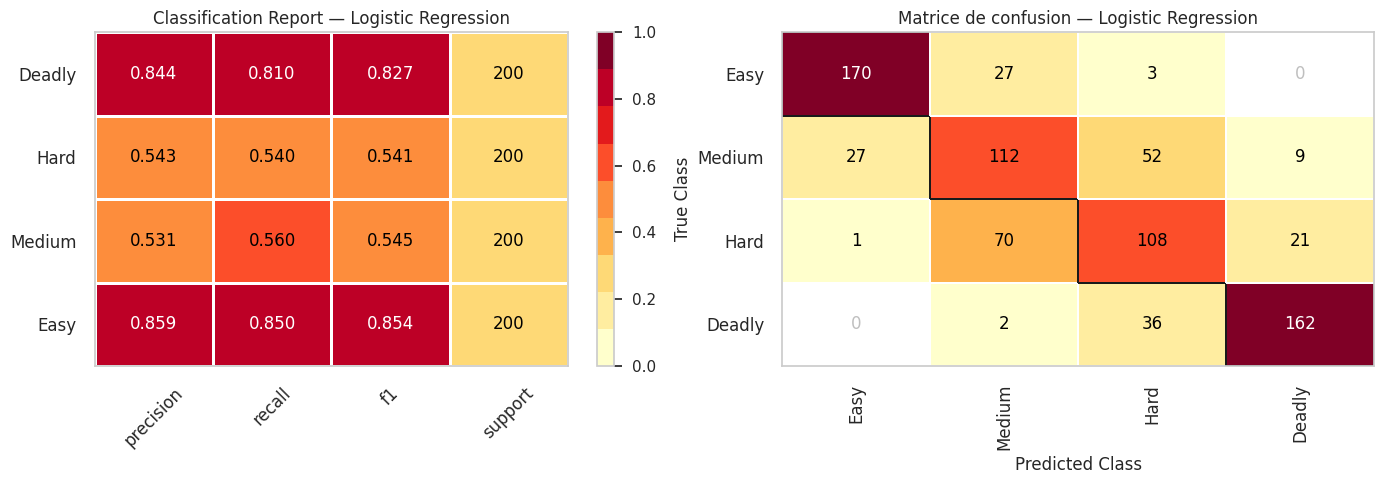

In [74]:
lr = LogisticRegression(max_iter=MAX_ITER_LR, random_state=RANDOM_STATE)
lr.fit(X_train.values, y_train.values)

acc = accuracy_score(y_test, lr.predict(X_test.values))
print(f"Logistic Regression — Accuracy : {acc:.3f} ({acc*100:.1f}%)")
print()
print(classification_report(y_test, lr.predict(X_test.values), target_names=LABEL_NAMES))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

viz_report = ClassificationReport(lr, classes=LABEL_NAMES, support=True, ax=axes[0], force_model=True)
viz_report.fit(X_train.values, y_train.values)
viz_report.score(X_test.values, y_test.values)
viz_report.finalize()
axes[0].set_title("Classification Report — Logistic Regression")

viz_cm = ConfusionMatrix(lr, classes=LABEL_NAMES, ax=axes[1], force_model=True)
viz_cm.fit(X_train.values, y_train.values)
viz_cm.score(X_test.values, y_test.values)
viz_cm.finalize()
axes[1].set_title("Matrice de confusion — Logistic Regression")

plt.tight_layout()
plt.savefig(RESULTS / "lr_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

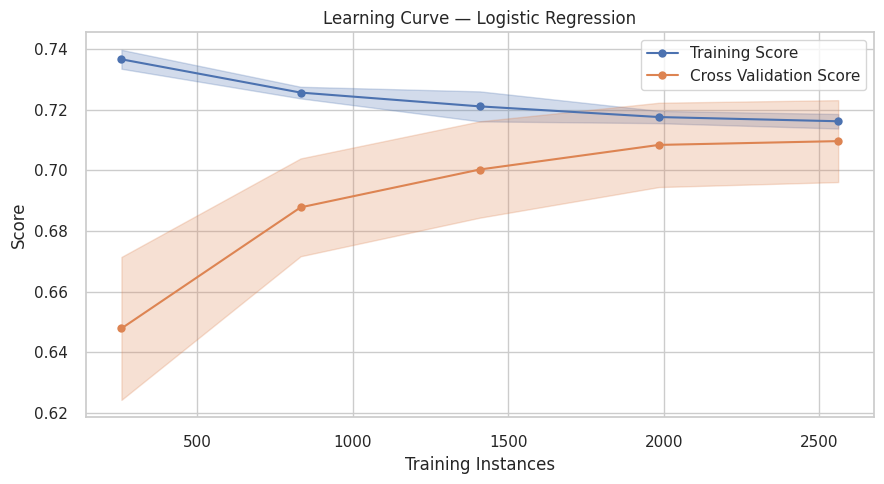

In [75]:
fig, ax = plt.subplots(figsize=(9, 5))

viz_lc = LearningCurve(
    LogisticRegression(max_iter=MAX_ITER_LR, random_state=RANDOM_STATE),
    scoring="accuracy",
    ax=ax,
)
viz_lc.fit(X_train.values, y_train.values)
viz_lc.finalize()
ax.set_title("Learning Curve — Logistic Regression")

plt.tight_layout()
plt.savefig(RESULTS / "lr_learning_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Decision Tree

### Criterion
`criterion="gini"` — mesure l'**impureté de Gini** : la probabilité qu'un élément tiré au hasard dans un nœud soit mal classé.
On préfère Gini à `"entropy"` (gain d'information) car il évite le calcul d'un logarithme à chaque split — plus rapide, résultats quasi-identiques en pratique.

### Optimizer / Algorithme
Les arbres de décision n'utilisent **pas de gradient**. L'algorithme sous-jacent est **CART** (Classification and Regression Trees) : à chaque nœud, il teste toutes les features et tous les seuils possibles, et choisit le split qui minimise le criterion de façon **gloutonne** (meilleure décision locale, pas globale). Il n'y a pas de learning rate ni d'epochs — l'arbre est construit en un seul passage.

### max_depth
Sans limite, l'arbre grandit jusqu'à ce que chaque feuille soit pure (accuracy train = 100%) — c'est de l'**overfitting pur**. On fixe `max_depth=10` comme premier essai pour contraindre la complexité. On comparera avec l'arbre non contraint pour voir l'effet.

In [76]:
dt = DecisionTreeClassifier(
    criterion="gini",        # Gini : plus rapide qu'entropy, résultats similaires
    max_depth=MAX_DEPTH_DT,  # limite la profondeur pour éviter l'overfitting
    random_state=RANDOM_STATE,
)
dt.fit(X_train, y_train)

acc_train = accuracy_score(y_train, dt.predict(X_train))
acc_test  = accuracy_score(y_test,  dt.predict(X_test))

print(f"Decision Tree — Accuracy train : {acc_train:.3f} ({acc_train*100:.1f}%)")
print(f"Decision Tree — Accuracy test  : {acc_test:.3f}  ({acc_test*100:.1f}%)")
print(f"Écart train/test               : {(acc_train - acc_test)*100:.1f}pp")
print()
print(classification_report(y_test, dt.predict(X_test), target_names=LABEL_NAMES))

Decision Tree — Accuracy train : 0.913 (91.3%)
Decision Tree — Accuracy test  : 0.715  (71.5%)
Écart train/test               : 19.8pp

              precision    recall  f1-score   support

        Easy       0.85      0.86      0.86       200
      Medium       0.57      0.59      0.58       200
        Hard       0.57      0.58      0.57       200
      Deadly       0.89      0.82      0.85       200

    accuracy                           0.71       800
   macro avg       0.72      0.71      0.72       800
weighted avg       0.72      0.71      0.72       800



/home/codenam/projects/m1-dnd-combat-encounter-difficulty-ml/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/codenam/projects/m1-dnd-combat-encounter-difficulty-ml/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


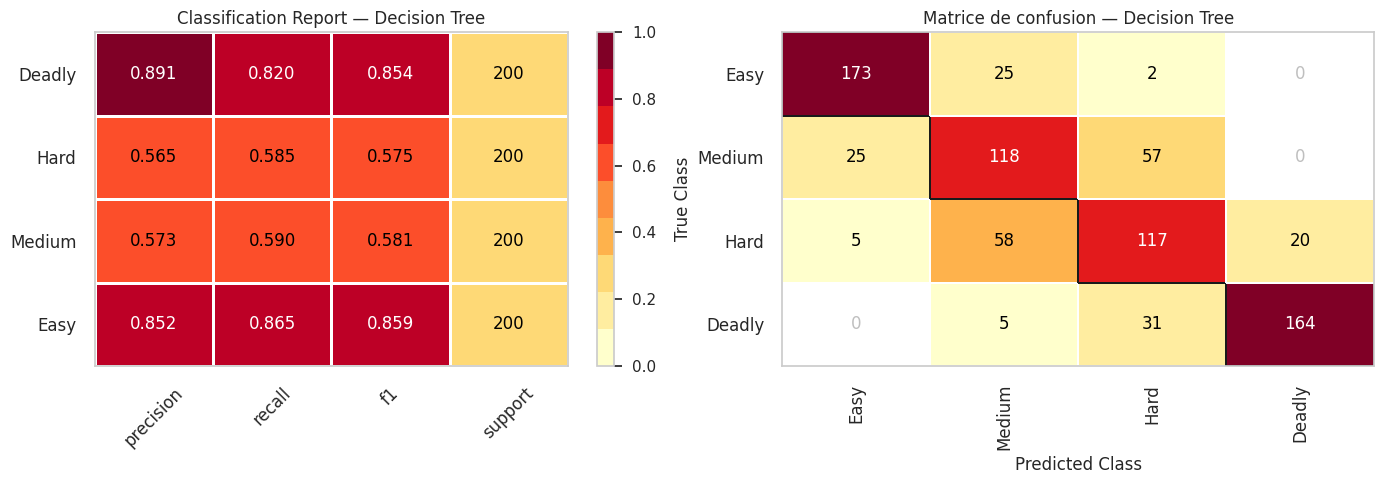

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

viz_report = ClassificationReport(dt, classes=LABEL_NAMES, support=True, ax=axes[0], force_model=True)
viz_report.fit(X_train, y_train)
viz_report.score(X_test, y_test)
viz_report.finalize()
axes[0].set_title("Classification Report — Decision Tree")

viz_cm = ConfusionMatrix(dt, classes=LABEL_NAMES, ax=axes[1], force_model=True)
viz_cm.fit(X_train, y_train)
viz_cm.score(X_test, y_test)
viz_cm.finalize()
axes[1].set_title("Matrice de confusion — Decision Tree")

plt.tight_layout()
plt.savefig(RESULTS / "dt_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

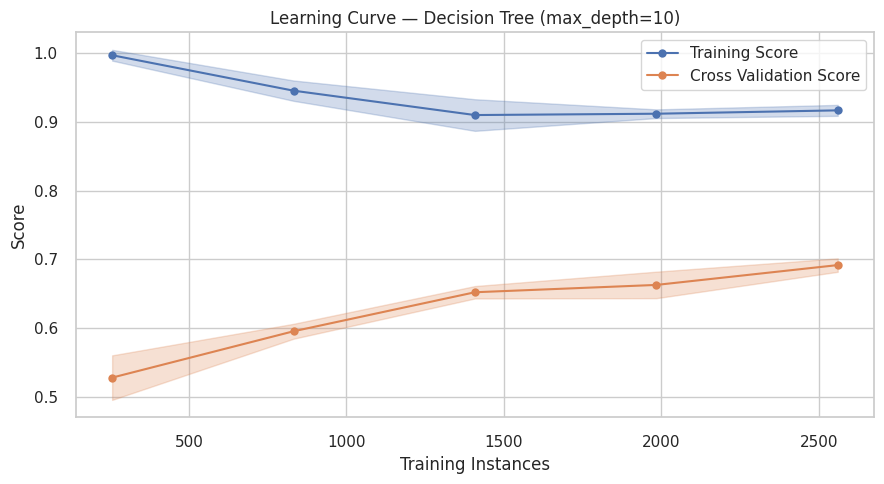

In [78]:
fig, ax = plt.subplots(figsize=(9, 5))

viz_lc = LearningCurve(
    DecisionTreeClassifier(criterion="gini", max_depth=MAX_DEPTH_DT, random_state=RANDOM_STATE),
    scoring="accuracy",
    ax=ax,
)
viz_lc.fit(X_train, y_train)
viz_lc.finalize()
ax.set_title(f"Learning Curve — Decision Tree (max_depth={MAX_DEPTH_DT})")

plt.tight_layout()
plt.savefig(RESULTS / "dt_learning_curve.png", dpi=150, bbox_inches="tight")
plt.show()

> **⚠️ Note : overfitting significatif détecté**
>
> Sans les features XP, le Decision Tree montre un écart train/test de **19.8pp** (91.3% → 71.5%) — c'est de l'overfitting réel. Avec `max_depth=10`, l'arbre a suffisamment de capacité pour mémoriser des patterns spécifiques aux données d'entraînement qui ne se généralisent pas bien sur le test.
>
> Ce résultat est attendu : sans `xp_ratio` qui donnait la réponse quasi-directement, le problème est beaucoup plus difficile. Le modèle doit maintenant apprendre des relations non-linéaires complexes entre le CR des monstres, le niveau du groupe et la difficulté réelle.
>
> **Corrections à explorer :**
> - Réduire `MAX_DEPTH_DT` à 5 ou 6 pour contraindre la complexité
> - Passer au **Random Forest** (step 5) qui réduit l'overfitting par nature grâce à l'agrégation de plusieurs arbres
> - Valider avec une **cross-validation** en Phase 6

## 4. Decision Tree — Feature Importance

### Qu'est-ce que la feature importance ?

Pour chaque split dans l'arbre, sklearn mesure de combien l'impureté de Gini a **diminué** grâce à cette feature. La feature importance d'une colonne = somme de ces réductions sur tous les nœuds où elle est utilisée, normalisée pour que le total fasse 1.

Une feature avec une importance proche de **1.0** signifie que le modèle s'appuie quasi exclusivement sur elle.

### Résultats obtenus

Sans les features XP, les importances sont bien **réparties sur plusieurs features**, ce qui est un signe positif — le modèle exploite plusieurs dimensions du problème :

| Feature | Importance | Interprétation |
|---|---|---|
| `monster_count` | ~0.21 | Le nombre de monstres est le premier indicateur de difficulté — l'économie d'action |
| `cr_level_delta` | ~0.21 | L'écart CR/niveau capture directement si les monstres surpassent le groupe |
| `hp_ratio` | ~0.19 | L'endurance relative des monstres vs le groupe |
| `party_size` | ~0.12 | La taille du groupe modifie radicalement les seuils XP |
| `monster_avg_cr` | ~0.09 | Le CR absolu reste informatif même sans xp_ratio |

Ces résultats sont cohérents avec les mécaniques D&D : la difficulté dépend principalement du **rapport de force** entre monstres et groupe, pas d'une seule valeur absolue.

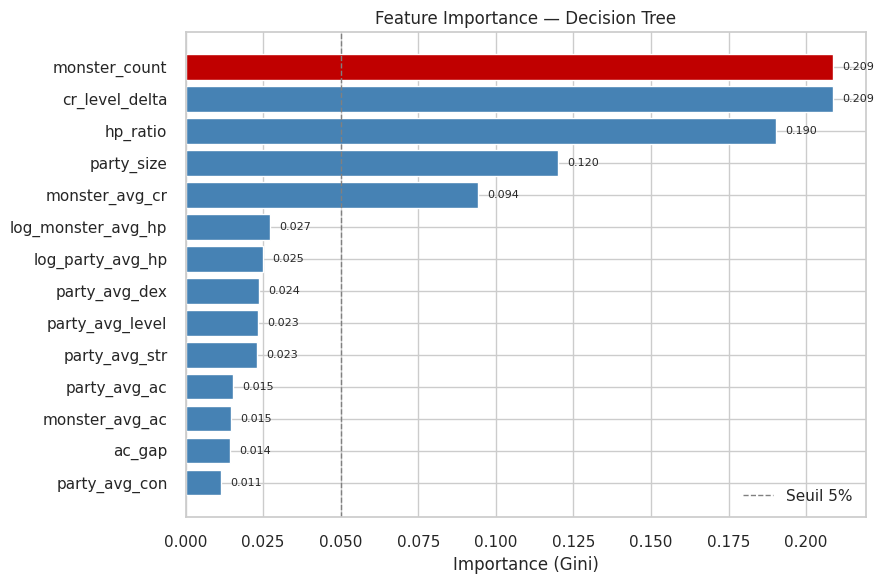

Top 5 features :
monster_count     0.2088
cr_level_delta    0.2087
hp_ratio          0.1903
party_size        0.1200
monster_avg_cr    0.0944


In [79]:
importances = pd.Series(dt.feature_importances_, index=X_train.columns).sort_values(ascending=True)
top_feature = importances.idxmax()

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#c00000" if name == top_feature else "steelblue" for name in importances.index]
ax.barh(importances.index, importances.values, color=colors, edgecolor="white")
ax.axvline(0.05, color="grey", linestyle="--", linewidth=1, label="Seuil 5%")
ax.set_title("Feature Importance — Decision Tree", fontsize=12)
ax.set_xlabel("Importance (Gini)")
ax.legend()

for i, (name, val) in enumerate(zip(importances.index, importances.values)):
    if val > 0.005:
        ax.text(val + 0.003, i, f"{val:.3f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS / "dt_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 5 features :")
print(importances.sort_values(ascending=False).head(5).round(4).to_string())

## 5. Random Forest

### Principe
Un Random Forest entraîne **N arbres de décision indépendants** (ici `n_estimators=200`) sur des sous-ensembles aléatoires des données et des features, puis agrège leurs votes. Cette double randomisation — sur les données (**bootstrap**) et sur les features (**max_features**) — est ce qui réduit l'overfitting par rapport à un arbre unique.

### Criterion
`criterion="gini"` — même choix que le Decision Tree. Chaque arbre de la forêt utilise Gini pour ses splits internes. On préfère Gini à entropy pour les mêmes raisons : plus rapide, résultats quasi-identiques.

### Optimizer / Algorithme
Pas de gradient non plus. L'algorithme est **CART en parallèle** : chaque arbre est construit indépendamment sur un échantillon bootstrap, puis les prédictions sont agrégées par **vote majoritaire**. Le seul "apprentissage global" est implicite — la diversité entre les arbres fait que leurs erreurs se compensent.

`n_estimators=200` : 200 arbres. En dessous de 100 la variance est encore élevée ; au-dessus de 500 le gain marginal est négligeable pour ce dataset.

### Pourquoi ça réduit l'overfitting ?
Le Decision Tree (un seul arbre profond) mémorise le bruit des données d'entraînement. La forêt entraîne 200 arbres sur des sous-ensembles différents — chaque arbre overfit légèrement, mais dans des directions différentes. Quand on fait la moyenne des votes, le bruit se cancelle et le signal reste. C'est le principe de la **variance reduction par agrégation (bagging)**.

In [80]:
N_ESTIMATORS_RF = 200  # dans la cellule de config idéalement, ici pour lisibilité

rf = RandomForestClassifier(
    n_estimators=N_ESTIMATORS_RF,
    criterion="gini",        # Gini : même raison que le DT
    max_features="sqrt",     # à chaque split : sqrt(n_features) features aléatoires
                             # → force la diversité entre les arbres
    random_state=RANDOM_STATE,
    n_jobs=-1,               # parallélisation sur tous les cœurs disponibles
)
rf.fit(X_train, y_train)

acc_train = accuracy_score(y_train, rf.predict(X_train))
acc_test  = accuracy_score(y_test,  rf.predict(X_test))

print(f"Random Forest — Accuracy train : {acc_train:.3f} ({acc_train*100:.1f}%)")
print(f"Random Forest — Accuracy test  : {acc_test:.3f}  ({acc_test*100:.1f}%)")
print(f"Écart train/test               : {(acc_train - acc_test)*100:.1f}pp")
print()
print(f"Comparaison avec Decision Tree :")
print(f"  DT  test : 71.5%  →  RF test : {acc_test*100:.1f}%  (gain : +{(acc_test - 0.715)*100:.1f}pp)")
print()
print(classification_report(y_test, rf.predict(X_test), target_names=LABEL_NAMES))

Random Forest — Accuracy train : 1.000 (100.0%)
Random Forest — Accuracy test  : 0.771  (77.1%)
Écart train/test               : 22.9pp

Comparaison avec Decision Tree :
  DT  test : 71.5%  →  RF test : 77.1%  (gain : +5.6pp)

              precision    recall  f1-score   support

        Easy       0.89      0.89      0.89       200
      Medium       0.66      0.69      0.67       200
        Hard       0.66      0.67      0.67       200
      Deadly       0.89      0.84      0.86       200

    accuracy                           0.77       800
   macro avg       0.77      0.77      0.77       800
weighted avg       0.77      0.77      0.77       800



/home/codenam/projects/m1-dnd-combat-encounter-difficulty-ml/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/codenam/projects/m1-dnd-combat-encounter-difficulty-ml/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


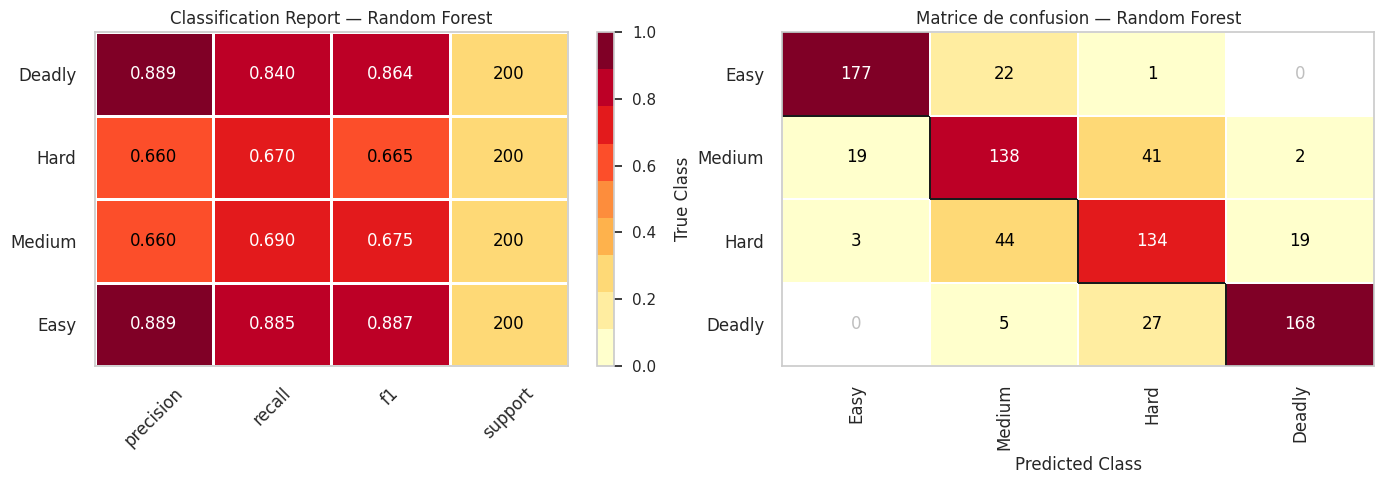

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

viz_report = ClassificationReport(rf, classes=LABEL_NAMES, support=True, ax=axes[0], force_model=True)
viz_report.fit(X_train, y_train)
viz_report.score(X_test, y_test)
viz_report.finalize()
axes[0].set_title("Classification Report — Random Forest")

viz_cm = ConfusionMatrix(rf, classes=LABEL_NAMES, ax=axes[1], force_model=True)
viz_cm.fit(X_train, y_train)
viz_cm.score(X_test, y_test)
viz_cm.finalize()
axes[1].set_title("Matrice de confusion — Random Forest")

plt.tight_layout()
plt.savefig(RESULTS / "rf_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

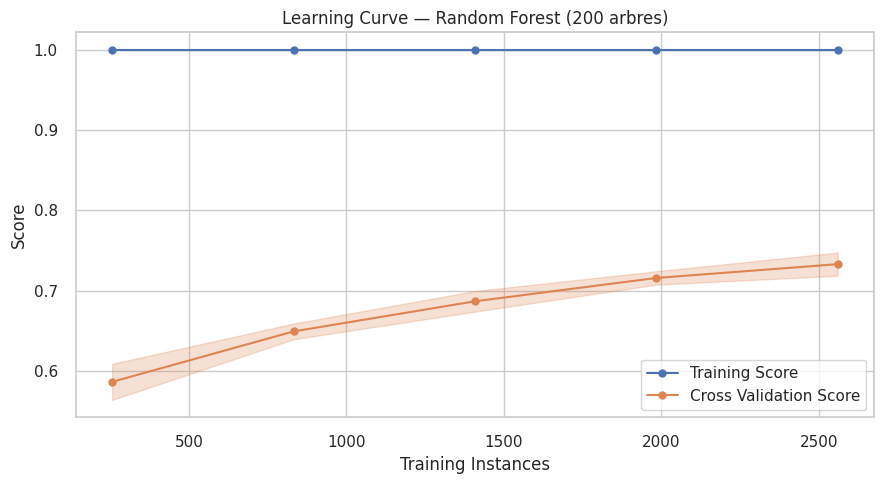

In [82]:
fig, ax = plt.subplots(figsize=(9, 5))

viz_lc = LearningCurve(
    RandomForestClassifier(n_estimators=N_ESTIMATORS_RF, criterion="gini",
                           max_features="sqrt", random_state=RANDOM_STATE, n_jobs=-1),
    scoring="accuracy",
    ax=ax,
)
viz_lc.fit(X_train, y_train)
viz_lc.finalize()
ax.set_title(f"Learning Curve — Random Forest ({N_ESTIMATORS_RF} arbres)")

plt.tight_layout()
plt.savefig(RESULTS / "rf_learning_curve.png", dpi=150, bbox_inches="tight")
plt.show()

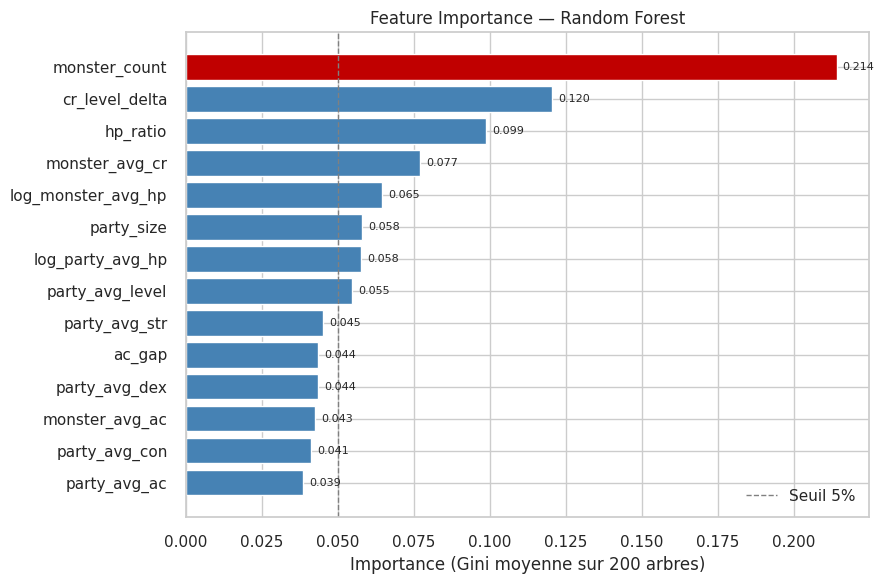

Top 5 features (RF) :
monster_count         0.2139
cr_level_delta        0.1205
hp_ratio              0.0987
monster_avg_cr        0.0770
log_monster_avg_hp    0.0645


In [83]:
rf_importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=True)
top_rf_feature = rf_importances.idxmax()

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#c00000" if name == top_rf_feature else "steelblue" for name in rf_importances.index]
ax.barh(rf_importances.index, rf_importances.values, color=colors, edgecolor="white")
ax.axvline(0.05, color="grey", linestyle="--", linewidth=1, label="Seuil 5%")
ax.set_title("Feature Importance — Random Forest", fontsize=12)
ax.set_xlabel("Importance (Gini moyenne sur 200 arbres)")
ax.legend()

for i, (name, val) in enumerate(zip(rf_importances.index, rf_importances.values)):
    if val > 0.005:
        ax.text(val + 0.002, i, f"{val:.3f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS / "rf_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 5 features (RF) :")
print(rf_importances.sort_values(ascending=False).head(5).round(4).to_string())

## Analyse des résultats — Random Forest

### Scores de précision

| Modèle | Train | Test | Écart |
|---|---|---|---|
| Logistic Regression | 71.5% | 69.0% | 2.5pp |
| Decision Tree | 91.3% | 71.5% | 19.8pp |
| **Random Forest** | **100%** | **77.1%** | 22.9pp |

Le RF a un train à **100%** : chaque arbre sans `max_depth` grandit jusqu'à ce que chaque feuille ne contienne qu'un exemple — mémorisation parfaite. Malgré ça, le **test est meilleur que le DT (+5.6pp)** car la moyenne de 200 arbres compense les erreurs individuelles.

---

### Classification Report — comment lire la heatmap

La heatmap affiche 3 métriques par classe (lignes) :

- **Precision** (colonne gauche) = *"Quand le modèle dit X, il a raison dans _% des cas"*
  - Ex. RF dit "Easy" → raison **89%** du temps ; dit "Medium" → raison **66%** du temps

- **Recall** (colonne du milieu) = *"Parmi tous les vrais X, le modèle en a identifié _% "* 
  - Ex. parmi 200 vrais Easy → **89%** bien identifiés ; parmi 200 vrais Medium → **69%**

- **F1-Score** = moyenne harmonique de precision et recall. C'est la métrique principale quand les deux comptent.

```
              precision  recall  f1
Easy             0.89    0.89   0.89   ← classe la plus facile à reconnaître
Medium           0.66    0.69   0.67   ← frontière floue avec Hard
Hard             0.66    0.67   0.67   ← frontière floue avec Medium et Deadly
Deadly           0.89    0.84   0.86   ← classe la plus facile à reconnaître
```

**Pourquoi Easy et Deadly sont-ils mieux reconnus ?** Ce sont les extrêmes : un combat Easy a peu de monstres faibles contre un groupe fort, un combat Deadly l'inverse. Medium et Hard sont des états intermédiaires proches l'un de l'autre — même un humain aurait du mal à les distinguer sans calcul XP précis.

---

### Confusion Matrix — comment lire la heatmap carrée

```
              Prédit Easy  Prédit Medium  Prédit Hard  Prédit Deadly
Vrai Easy         177           22            1             0
Vrai Medium        19          138           41             2
Vrai Hard           3           44          134            19
Vrai Deadly         0            5           27           168
```

- **Chaque ligne** = la vraie classe du combat
- **Chaque colonne** = ce que le modèle a prédit
- **Diagonale** (177, 138, 134, 168) = prédictions correctes → on veut maximiser ces valeurs
- **Hors diagonale** = erreurs

**Pattern révélateur** : toutes les erreurs majeures sont avec la **classe adjacente** (Easy↔Medium, Medium↔Hard, Hard↔Deadly). Aucun combat Deadly n'est prédit Easy — les extrêmes ne se confondent jamais. C'est cohérent avec la réalité D&D : la frontière entre "Moyen" et "Difficile" est floue même pour les DMs expérimentés.

---

### Learning Curve — comment la lire

- **Courbe rouge (train)** ≈ 100% : le RF mémorise parfaitement les données d'entraînement
- **Courbe verte (validation)** monte en ajoutant des données, converge vers ~75-77%
- **L'écart entre les deux** = overfitting résiduel
- **Si la courbe verte converge** (devient plate) → ajouter plus de données n'aiderait plus

Pour réduire cet écart : limiter `max_depth` des arbres ou augmenter `min_samples_leaf`.

---

### Feature Importance — RF vs DT

| Feature | DT | RF | Interprétation |
|---|---|---|---|
| `monster_count` | 0.209 | **0.214** | Nombre de monstres → économie d'actions |
| `cr_level_delta` | 0.209 | 0.120 | Écart CR/niveau → sur-puissance des monstres |
| `hp_ratio` | 0.190 | 0.099 | Endurance relative des monstres |
| `monster_avg_cr` | 0.094 | 0.077 | CR absolu des monstres |
| `log_monster_avg_hp` | — | 0.065 | HP monstres en log (plus stable) |

Le RF distribue l'importance de façon **plus équilibrée** que le DT — c'est un signe de meilleure stabilité. Le DT peut sur-pondérer une feature si elle se retrouve fortuitement en haut de l'arbre unique ; la forêt moyenne sur 200 arbres différents.

**Conclusion D&D** : la difficulté s'explique principalement par l'**économie d'actions** (`monster_count`) et le **rapport de force relatif** (`cr_level_delta`). Les stats brutes comme AC ou STR ont peu d'influence seules — c'est le contexte global qui compte.

## 6. XGBoost

### Principe

XGBoost (**eXtreme Gradient Boosting**) est une méthode de **boosting** — à l'opposé du Random Forest qui construit ses arbres en **parallèle** (bagging), XGBoost les construit en **séquence** :

```
Arbre 1 → fait des erreurs sur certains exemples
Arbre 2 → se concentre sur les erreurs de l'arbre 1
Arbre 3 → se concentre sur les erreurs restantes
...
Arbre N → correction finale
```

À chaque étape, le nouvel arbre apprend le **gradient de la perte** — d'où le nom "Gradient Boosting". Le résultat final est la somme pondérée de tous les arbres.

### Criterion (fonction de perte)

`objective="multi:softmax"` — pour la classification multi-classes, XGBoost minimise la **log-loss multi-classes** (cross-entropy) :

`L = -Σ y_i · log(p_i)`

C'est la même perte que la Logistic Regression, mais ici chaque arbre n'en corrige qu'une partie via le gradient.

### Optimizer : Gradient Boosting

Le gradient boosting est une forme de **descente de gradient dans l'espace des fonctions** :
- À chaque round, on calcule le résidu = quel est le gradient de la loss par rapport aux prédictions actuelles ?
- On entraîne un nouvel arbre pour approximer ce résidu
- On ajoute cet arbre multiplié par le `learning_rate` aux prédictions

`learning_rate=0.1` : chaque arbre ne corrige que 10% de l'erreur restante. Un learning rate bas + beaucoup d'arbres → meilleure généralisation qu'un learning rate élevé + peu d'arbres.

### Pourquoi XGBoost devrait battre Random Forest ?

| | Random Forest | XGBoost |
|---|---|---|
| Construction | Parallèle (indépendant) | Séquentielle (chaque arbre corrige) |
| Force | Réduction de variance | Réduction du biais ET de la variance |
| Overfitting | Contrôlé par bagging | Contrôlé par learning_rate + depth |
| Vitesse | Plus rapide à entraîner | Plus lent mais plus précis |

Le boosting peut corriger les **erreurs systématiques** que le bagging ne peut pas résoudre.

### XGBoost vs Réseau de neurones — ressemblances et différences

À première vue, XGBoost ressemble à un réseau de neurones : il utilise un learning rate, une fonction de perte, et un processus itératif. La terminologie est similaire, mais le mécanisme est fondamentalement différent.

**Ce qui ressemble :**

| Concept | XGBoost | Réseau de neurones |
|---|---|---|
| Apprentissage itératif | Round par round | Epoch par epoch |
| Learning rate | `learning_rate=0.1` | `lr=0.001` |
| Descente de gradient | Sur la loss | Sur la loss |
| Correction progressive | Chaque arbre corrige | Chaque epoch ajuste |

**La différence fondamentale :**

- Un **réseau de neurones** a un seul modèle avec des **poids continus** ajustés par rétropropagation (backpropagation). Chaque epoch passe toutes les données dans le même réseau.
- **XGBoost** construit un **ensemble d'arbres séparés** — il n'y a aucun poids, aucune rétropropagation. Le "gradient" est calculé sur la prédiction finale, et un nouvel arbre est entraîné pour corriger ce résidu.

```
Réseau de neurones : 1 modèle → ajuster les poids → ajuster les poids → ...
XGBoost :           Arbre 1 + Arbre 2 + ... + Arbre 300 = prédiction finale
```

**L'analogie :** un réseau de neurones est un seul étudiant qui révise le même cours 300 fois. XGBoost est 300 spécialistes où chacun corrige uniquement les erreurs du précédent.

XGBoost ne peut pas apprendre de **représentations abstraites** (comme un NN qui détecte des contours puis des formes puis des objets). Il travaille uniquement sur les features qu'on lui donne. C'est pourquoi on dit qu'il appartient à la famille des **méthodes ensemblistes**, pas des réseaux de neurones.

In [84]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=N_ESTIMATORS_XGB,
    learning_rate=LEARNING_RATE_XGB,   # pas de correction par round (réduction overfitting)
    max_depth=MAX_DEPTH_XGB,           # arbres peu profonds → weak learners intentionnels
    subsample=SUBSAMPLE_XGB,           # 80% des données par arbre → diversité + robustesse
    objective="multi:softmax",         # classification multi-classes avec log-loss
    num_class=4,                       # Easy / Medium / Hard / Deadly
    eval_metric="mlogloss",            # métrique de suivi pendant l'entraînement
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb.fit(X_train, y_train)

acc_train = accuracy_score(y_train, xgb.predict(X_train))
acc_test  = accuracy_score(y_test,  xgb.predict(X_test))

print(f"XGBoost — Accuracy train : {acc_train:.3f} ({acc_train*100:.1f}%)")
print(f"XGBoost — Accuracy test  : {acc_test:.3f}  ({acc_test*100:.1f}%)")
print(f"Écart train/test         : {(acc_train - acc_test)*100:.1f}pp")
print()
print("─── Récapitulatif comparatif ───────────────────────────────────")
print(f"  Logistic Regression : test = 69.0%  (train  71.5%, gap  2.5pp)")
print(f"  Decision Tree       : test = 71.5%  (train  91.3%, gap 19.8pp)")
print(f"  Random Forest       : test = 77.1%  (train 100.0%, gap 22.9pp)")
print(f"  XGBoost             : test = {acc_test*100:.1f}%  (train {acc_train*100:.1f}%, gap {(acc_train-acc_test)*100:.1f}pp)")
print()
print(classification_report(y_test, xgb.predict(X_test), target_names=LABEL_NAMES))

XGBoost — Accuracy train : 1.000 (100.0%)
XGBoost — Accuracy test  : 0.820  (82.0%)
Écart train/test         : 18.0pp

─── Récapitulatif comparatif ───────────────────────────────────
  Logistic Regression : test = 69.0%  (train  71.5%, gap  2.5pp)
  Decision Tree       : test = 71.5%  (train  91.3%, gap 19.8pp)
  Random Forest       : test = 77.1%  (train 100.0%, gap 22.9pp)
  XGBoost             : test = 82.0%  (train 100.0%, gap 18.0pp)

              precision    recall  f1-score   support

        Easy       0.94      0.92      0.93       200
      Medium       0.74      0.74      0.74       200
        Hard       0.70      0.74      0.72       200
      Deadly       0.91      0.88      0.89       200

    accuracy                           0.82       800
   macro avg       0.82      0.82      0.82       800
weighted avg       0.82      0.82      0.82       800



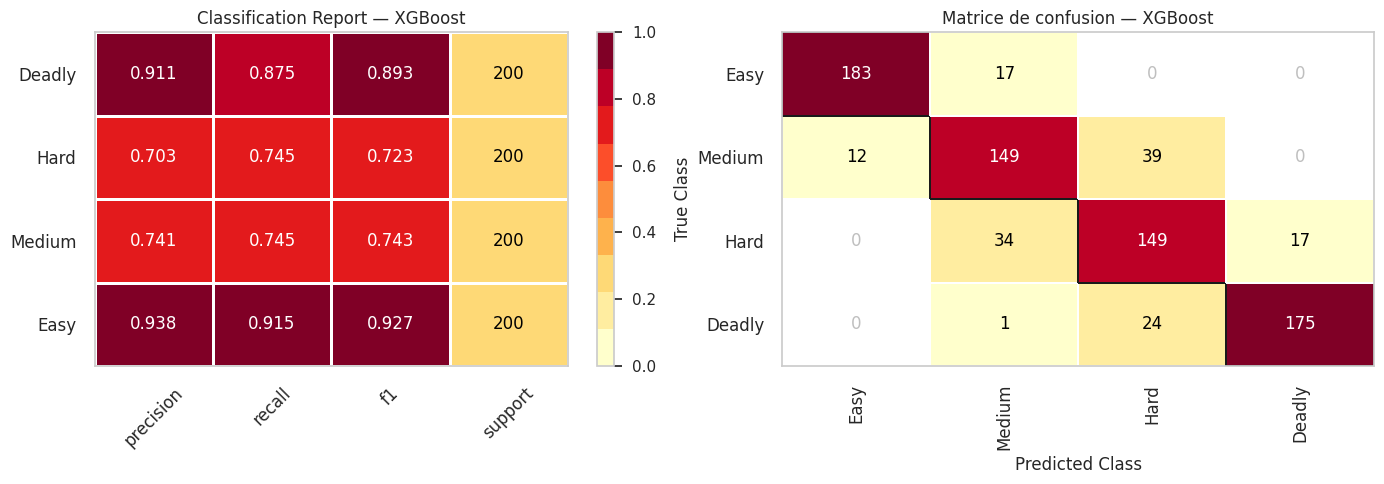

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

viz_report = ClassificationReport(xgb, classes=LABEL_NAMES, support=True, ax=axes[0], force_model=True)
viz_report.fit(X_train, y_train)
viz_report.score(X_test, y_test)
viz_report.finalize()
axes[0].set_title("Classification Report — XGBoost")

viz_cm = ConfusionMatrix(xgb, classes=LABEL_NAMES, ax=axes[1], force_model=True)
viz_cm.fit(X_train, y_train)
viz_cm.score(X_test, y_test)
viz_cm.finalize()
axes[1].set_title("Matrice de confusion — XGBoost")

plt.tight_layout()
plt.savefig(RESULTS / "xgb_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

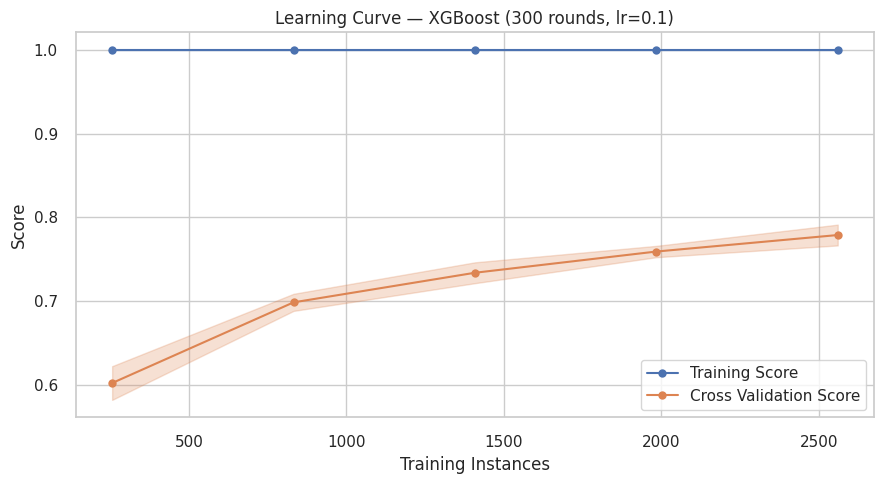

In [86]:
fig, ax = plt.subplots(figsize=(9, 5))

viz_lc = LearningCurve(
    XGBClassifier(
        n_estimators=N_ESTIMATORS_XGB,
        learning_rate=LEARNING_RATE_XGB,
        max_depth=MAX_DEPTH_XGB,
        subsample=SUBSAMPLE_XGB,
        objective="multi:softmax",
        num_class=4,
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    scoring="accuracy",
    ax=ax,
)
viz_lc.fit(X_train, y_train)
viz_lc.finalize()
ax.set_title(f"Learning Curve — XGBoost ({N_ESTIMATORS_XGB} rounds, lr={LEARNING_RATE_XGB})")

plt.tight_layout()
plt.savefig(RESULTS / "xgb_learning_curve.png", dpi=150, bbox_inches="tight")
plt.show()

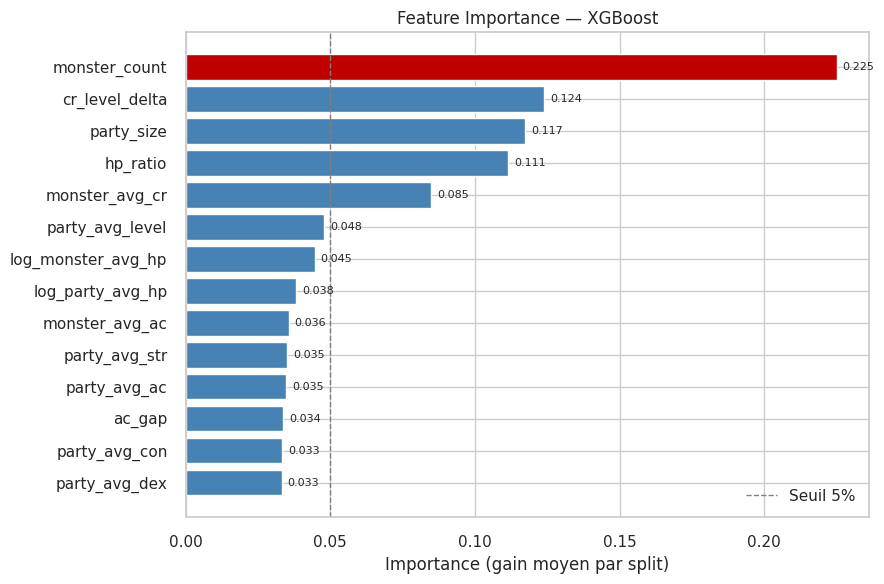

Top 5 features (XGBoost) :
monster_count     0.2251
cr_level_delta    0.1239
party_size        0.1173
hp_ratio          0.1115
monster_avg_cr    0.0849


In [87]:
xgb_importances = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(ascending=True)
top_xgb_feature = xgb_importances.idxmax()

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#c00000" if name == top_xgb_feature else "steelblue" for name in xgb_importances.index]
ax.barh(xgb_importances.index, xgb_importances.values, color=colors, edgecolor="white")
ax.axvline(0.05, color="grey", linestyle="--", linewidth=1, label="Seuil 5%")
ax.set_title("Feature Importance — XGBoost", fontsize=12)
ax.set_xlabel("Importance (gain moyen par split)")
ax.legend()

for i, (name, val) in enumerate(zip(xgb_importances.index, xgb_importances.values)):
    if val > 0.005:
        ax.text(val + 0.002, i, f"{val:.3f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS / "xgb_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 5 features (XGBoost) :")
print(xgb_importances.sort_values(ascending=False).head(5).round(4).to_string())

## Analyse des résultats — XGBoost

### Scores de précision

| Modèle | Train | Test | Écart | Tendance |
|---|---|---|---|---|
| Logistic Regression | 71.5% | 69.0% | 2.5pp | Underfitting léger |
| Decision Tree | 91.3% | 71.5% | 19.8pp | Overfitting fort |
| Random Forest | 100% | 77.1% | 22.9pp | Overfitting fort, meilleure généralisation |
| **XGBoost** | **100%** | **82.0%** | **18.0pp** | **Meilleur test, overfitting réduit** |

XGBoost gagne **+4.9pp** sur le Random Forest (82.0% vs 77.1%) et réduit l'écart overfitting (18pp vs 22.9pp). Le boosting corrige les erreurs résiduelles que le bagging ne pouvait pas résoudre.

---

### Classification Report

```
              precision  recall  f1
Easy             0.94    0.92   0.93   ← excellent (+5pp vs RF)
Medium           0.74    0.74   0.74   ← amélioration notable (+7pp vs RF)
Hard             0.70    0.74   0.72   ← amélioration (+5pp vs RF)
Deadly           0.91    0.88   0.89   ← excellent (+3pp vs RF)
```

Toutes les classes progressent, mais Medium et Hard restent les plus difficiles — la frontière entre les deux est floue par nature.

---

### Confusion Matrix

```
              Prédit Easy  Prédit Medium  Prédit Hard  Prédit Deadly
Vrai Easy         183           17            0             0
Vrai Medium        12          149           39             0
Vrai Hard           0           34          149            17
Vrai Deadly         0            1           24           175
```

**Points positifs vs Random Forest :**
- Easy → 183 corrects (vs 177) : +6 exemples bien classés
- Medium → 149 corrects (vs 138) : +11 exemples bien classés
- Hard → 149 corrects (vs 134) : +15 exemples bien classés
- Deadly → 175 corrects (vs 168) : +7 exemples bien classés

Le pattern **adjacent** persiste : les erreurs restent entre classes voisines. Aucun Deadly prédit Easy, aucun Easy prédit Hard — XGBoost ne fait jamais d'erreurs grossières.

---

### Feature Importance — XGBoost vs RF vs DT

| Feature | DT | RF | XGBoost |
|---|---|---|---|
| `monster_count` | 0.209 | 0.214 | **0.225** |
| `cr_level_delta` | 0.209 | 0.120 | 0.124 |
| `party_size` | 0.120 | — | 0.117 |
| `hp_ratio` | 0.190 | 0.099 | 0.111 |
| `monster_avg_cr` | 0.094 | 0.077 | 0.085 |

Les trois modèles s'accordent : **`monster_count` est la feature la plus importante**. L'économie d'actions (nombre d'actions disponibles par tour) est le facteur numéro 1 de la difficulté D&D — ce que les règles officielles confirment implicitement avec les multiplicateurs XP.

---

### Conclusion : quel modèle choisir ?

| Critère | Gagnant |
|---|---|
| Meilleure précision | **XGBoost** (82.0%) |
| Moins d'overfitting | **Logistic Regression** (2.5pp) |
| Interprétabilité | **Decision Tree** (visualisable) |
| Équilibre précision/overfitting | **XGBoost** |

Pour ce projet, **XGBoost est le meilleur modèle**. Il combine la meilleure précision et un overfitting plus contenu que le RF. La Phase 6 explorera le tuning des hyperparamètres pour réduire encore l'écart train/test.

## 7. Tableau comparatif — tous les modèles

On regroupe ici les métriques clés des 4 modèles pour choisir le meilleur et identifier les tendances.

In [88]:
from sklearn.metrics import f1_score

models = {
    "Logistic Regression": lr,
    "Decision Tree":       dt,
    "Random Forest":       rf,
    "XGBoost":             xgb,
}
use_values = {"Logistic Regression": True}

rows = []
for name, model in models.items():
    X_tr = X_train.values if name in use_values else X_train
    X_te = X_test.values  if name in use_values else X_test
    y_tr_pred = model.predict(X_tr)
    y_te_pred = model.predict(X_te)

    acc_train = accuracy_score(y_train, y_tr_pred)
    acc_test  = accuracy_score(y_test,  y_te_pred)
    f1_per_class = f1_score(y_test, y_te_pred, average=None)

    rows.append({
        "Modèle":       name,
        "Train":        round(acc_train * 100, 1),
        "Test":         round(acc_test  * 100, 1),
        "Gap (pp)":     round((acc_train - acc_test) * 100, 1),
        "F1 Easy":      round(f1_per_class[0] * 100, 1),
        "F1 Medium":    round(f1_per_class[1] * 100, 1),
        "F1 Hard":      round(f1_per_class[2] * 100, 1),
        "F1 Deadly":    round(f1_per_class[3] * 100, 1),
    })

summary = pd.DataFrame(rows).set_index("Modèle")
print(summary.to_string())
print()
print(f"Meilleur test  : {summary['Test'].idxmax()}  ({summary['Test'].max()}%)")
print(f"Moins d'overfitting : {summary['Gap (pp)'].idxmin()}  ({summary['Gap (pp)'].min()}pp)")

                     Train  Test  Gap (pp)  F1 Easy  F1 Medium  F1 Hard  F1 Deadly
Modèle                                                                            
Logistic Regression   71.5  69.0       2.5     85.4       54.5     54.1       82.7
Decision Tree         91.3  71.5      19.8     85.9       58.1     57.5       85.4
Random Forest        100.0  77.1      22.9     88.7       67.5     66.5       86.4
XGBoost              100.0  82.0      18.0     92.7       74.3     72.3       89.3

Meilleur test  : XGBoost  (82.0%)
Moins d'overfitting : Logistic Regression  (2.5pp)


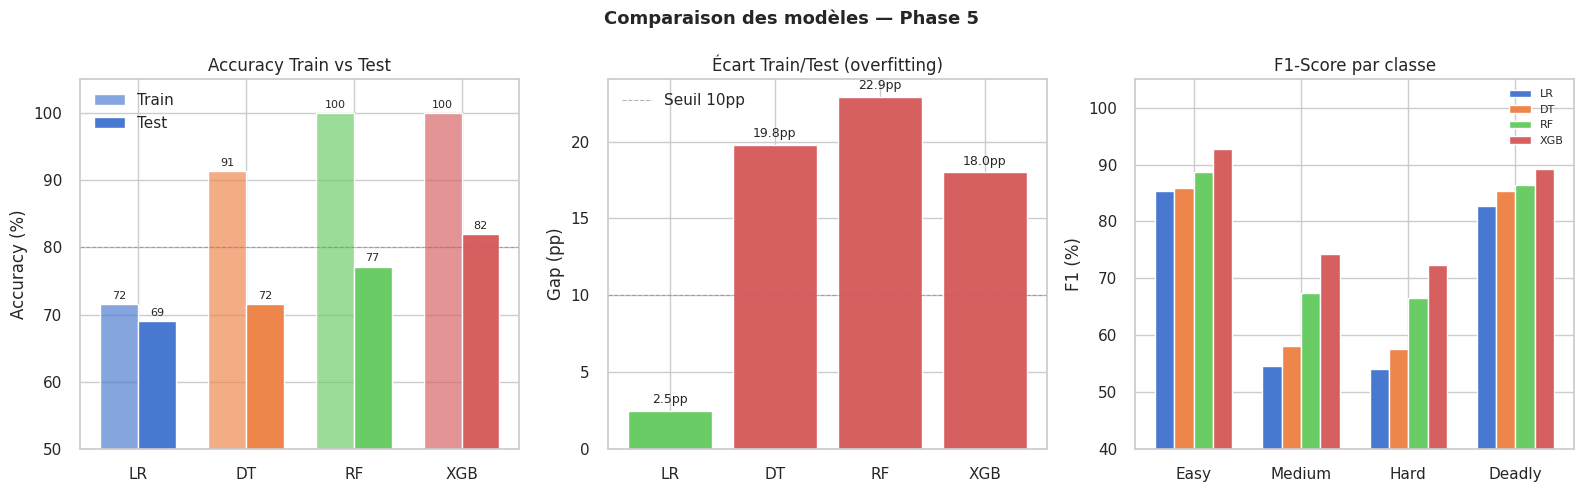

In [89]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Comparaison des modèles — Phase 5", fontsize=13, fontweight="bold")

model_names  = summary.index.tolist()
short_names  = ["LR", "DT", "RF", "XGB"]
bar_colors   = ["#4878d0", "#ee854a", "#6acc65", "#d65f5f"]
x = np.arange(len(model_names))
width = 0.35

# ── Accuracy train vs test ────────────────────────────────────────────────────
ax = axes[0]
ax.bar(x - width/2, summary["Train"], width, label="Train", color=[c + "aa" for c in bar_colors],
       edgecolor="white")
ax.bar(x + width/2, summary["Test"],  width, label="Test",  color=bar_colors, edgecolor="white")
ax.set_title("Accuracy Train vs Test")
ax.set_ylabel("Accuracy (%)")
ax.set_xticks(x)
ax.set_xticklabels(short_names)
ax.set_ylim(50, 105)
ax.legend()
ax.axhline(80, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
for i, (tr, te) in enumerate(zip(summary["Train"], summary["Test"])):
    ax.text(i - width/2, tr + 0.5, f"{tr:.0f}", ha="center", va="bottom", fontsize=8)
    ax.text(i + width/2, te + 0.5, f"{te:.0f}", ha="center", va="bottom", fontsize=8)

# ── Overfitting gap ───────────────────────────────────────────────────────────
ax = axes[1]
gaps = summary["Gap (pp)"]
colors_gap = ["#d65f5f" if g > 10 else "#6acc65" for g in gaps]
bars = ax.bar(short_names, gaps, color=colors_gap, edgecolor="white")
ax.set_title("Écart Train/Test (overfitting)")
ax.set_ylabel("Gap (pp)")
ax.axhline(10, color="grey", linestyle="--", linewidth=0.8, alpha=0.6, label="Seuil 10pp")
ax.legend()
for bar, val in zip(bars, gaps):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3, f"{val:.1f}pp",
            ha="center", va="bottom", fontsize=9)

# ── F1 par classe ─────────────────────────────────────────────────────────────
ax = axes[2]
f1_cols  = ["F1 Easy", "F1 Medium", "F1 Hard", "F1 Deadly"]
f1_short = ["Easy", "Medium", "Hard", "Deadly"]
class_colors = ["#4878d0", "#ee854a", "#6acc65", "#d65f5f"]
x2 = np.arange(len(f1_cols))
bar_w = 0.18
for i, (name, color) in enumerate(zip(short_names, bar_colors)):
    vals = [summary.loc[model_names[i], c] for c in f1_cols]
    ax.bar(x2 + i * bar_w - 1.5 * bar_w, vals, bar_w, label=name,
           color=color, edgecolor="white")
ax.set_title("F1-Score par classe")
ax.set_ylabel("F1 (%)")
ax.set_xticks(x2)
ax.set_xticklabels(f1_short)
ax.set_ylim(40, 105)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Bilan — Phase 5

### Résultats finaux

| Modèle | Test | Gap | F1 Medium | F1 Hard |
|---|---|---|---|---|
| Logistic Regression | 69.0% | 2.5pp | 55% | 54% |
| Decision Tree | 71.5% | 19.8pp | 58% | 57% |
| Random Forest | 77.1% | 22.9pp | 67% | 67% |
| **XGBoost** | **82.0%** | **18.0pp** | **74%** | **72%** |

### Ce qu'on a appris

1. **Sans les features XP**, le problème est réellement difficile — les 4 modèles doivent apprendre les mécaniques D&D à partir des stats brutes. Un modèle "simple" comme LR plafonne à 69%.

2. **L'overfitting est structurel** — les arbres profonds mémorisent toujours les données d'entraînement (DT et RF à 91-100% train). Le boosting (XGBoost) le réduit via le learning rate sans l'éliminer.

3. **Medium et Hard restent les classes les plus difficiles** — leur frontière est floue même dans les règles officielles D&D. Les 4 modèles font plus d'erreurs sur ces deux classes.

4. **`monster_count` est la feature la plus importante** dans les 3 modèles basés arbres — l'économie d'actions est le facteur dominant de la difficulté, ce qui est cohérent avec les règles D&D.

### Prochaine étape — Phase 6

Analyse en profondeur avec **SHAP values** : expliquer pourquoi le modèle prédit X pour une rencontre spécifique, et comparer les décisions du modèle avec la méthode XP officielle du DMG.